# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [2]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 2.60s
Prepared 45 packages in 1m 00s
Uninstalled 23 packages in 976ms
Installed 45 packages in 470ms
 - click==8.3.2
 + click==8.1.8
 + cyclopts==4.10.2
 - decorator==4.4.2
 + decorator==5.2.1
 + exca==0.5.22
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.12.0
 + mne-bids==0.18.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-cur

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [1]:
!pip install "numpy<2.0.0" "scipy>=1.10" "mne>=1.5"
# Sau khi chạy xong dòng trên, hãy Restart Runtime (Ctrl+M .) rồi chạy lại các cell.

from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-20 02:28:40 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-20 02:29:44 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [3]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)

from google.colab import files
from pathlib import Path
import shutil

uploaded = files.upload()
filename = next(iter(uploaded))

video_path = CACHE_FOLDER / filename
shutil.move(filename, video_path)


df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4


Saving 1_3873027869186972713.mp4 to 1_3873027869186972713.mp4


Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/1_3873027869186972713.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [02:51<00:00, 171.36s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 60/60 [00:00<00:00, 90492.00it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,19.320000,cache/1_3873027869186972713.wav,NaN,
1,Video,0.000000,19.320000,cache/1_3873027869186972713.mp4,NaN,
2,Sentence,0.190999,11.415002,NaN,Did you know that blending two boiled eggs wit...,
3,Text,0.191000,18.925000,NaN,Did you know that blending two boiled eggs wit...,
4,Word,0.191000,0.120000,NaN,Did,Did
5,Word,0.351000,0.081000,NaN,you,Did you
6,Word,0.492000,0.120000,NaN,know,Did you know
7,Word,0.652000,0.120000,NaN,that,Did you know that


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [4]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[02:36:27 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-04-20 02:39:38 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 19.32s at 30.0fps, shape (720, 1280)):
cache/1_3873027869186972713.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 19.32s at 30.0fps, shape (720, 1280)):
cache/1_3873027869186972713.mp4
Encoding video:   0%|          | 0/39 [00:00<?, ?it/s]2026-04-20 02:39:56 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (39, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (39, 20, 1408)
Encoding video: 100%|██████████| 39/39 [11:14<00:00, 17.30s/it]
[02:50:54 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-20 02:50:54 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[02:50:54 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624

Predictions shape: (20, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:04<00:00,  3.17it/s]


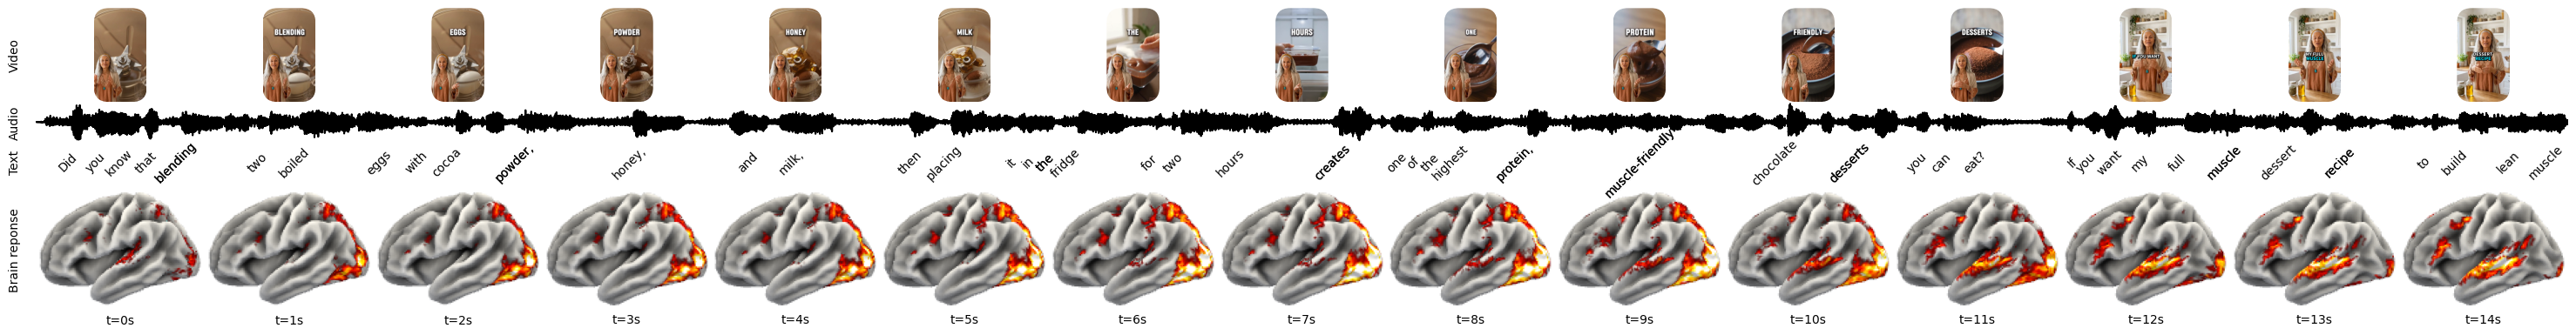

In [6]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [21]:
text = """
Do you wake up with a flat stomach, but look 6 months pregnant by dinner time? If you're eating clean but still feel like a balloon... you didn't gain fat. Your internal signals are just totally glitched out.
Look, you’ve spent your whole life taking care of everyone else. Now, your waistband is screaming and you have to unbutton your pants just to breathe. Your doctor says 'eat less,' but that’s useless. After 40, your internal 'engine' slows down. Imagine your gut like a massive traffic jam. Food sits there, it ferments, and it creates a ton of gas. It’s not a 'fat' problem—it’s a 'traffic' problem.
Why the jam? Because your hormones shifted and the 'trash truck' in your gut just stopped working. Everything piles up and gets gross. Dieting doesn't fix a traffic jam. You need a 'tow truck.' Science found certain herbs act like a clean-up crew to clear the pipes and flip your 'on' switch back on.
That’s why thousands of women are using MenoMate. It’s a pure herbal blend that fixes those glitched signals. No magic, just science. Most women feel that 'heavy' feeling vanish in weeks. They give you 90 days to try it—if your belly doesn't flatten, you get every penny back. Link in Bio. Go check if the sale is still live. You’ve taken care of everyone else long enough. Take care of you
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Do-you-wake-up-with-a-flat-stomach,-but-look-6-months-pregnant-by-dinner-time-If-youre-eating-clean-but-still-feel-like-a-...12-497683a8/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-Do-you-wake-up-with-a-flat-stomach,-but-look-6-months-pregnant-by-dinner-time-If-youre-eating-clean-but-still-feel-like-a-...12-497683a8/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:52<00:00, 52.82s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 470/470 [00:00<00:00, 94693.19it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,60.000000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,4.883002,NaN,"Do you wake up with a flat stomach, but look s...",
2,Text,0.091000,214.828000,NaN,"Do you wake up with a flat stomach, but look s...",
3,Word,0.091000,0.100000,NaN,Do,Do
4,Word,0.231000,0.100000,NaN,you,Do you
5,Word,0.371000,0.220000,NaN,wake,Do you wake
6,Word,0.671000,0.080000,NaN,up,Do you wake up
7,Word,0.811000,0.141000,NaN,with,Do you wake up with


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [22]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[04:15:35 WARNING] Removing extractor video as there are no corresponding events
[04:15:35 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/118 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

100%|██████████| 470/470 [10:53<00:00,  1.39s/it]

Computing word embeddings: 100%|██████████| 118/118 [10:53<00:00,  5.54s/it]
[04:26:31 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
Computing audio embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:18<00:00,  9.43s/it]

Computing audio embeddings: 100%|██████████| 2/2 [00:18<00:00,  9.43s/it]
[04:26:51 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-20 04:26:51 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[04:26:51 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
2026-04-20 04:26:51 - WARNING - neuralset.segments:759 - 2 segments out of 3 did not contain valid events for event type <class 'neuralset.events.etypes.Audio'>
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lowe

Predictions shape: (215, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.26it/s]


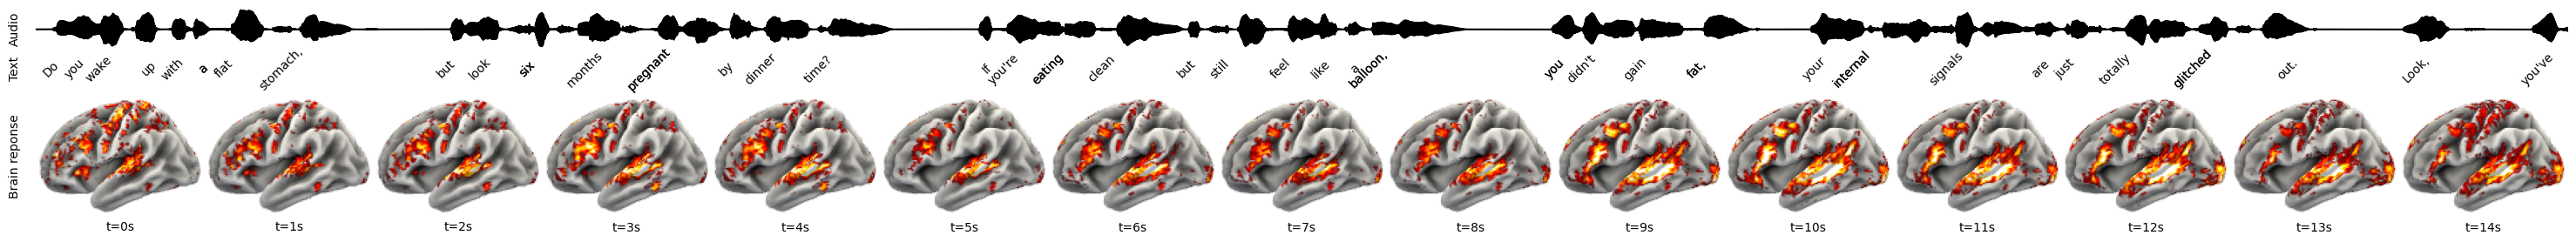

In [23]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)